<div style="background:linear-gradient(135deg,#022F35 0%,#0A3D45 60%,#124F5A 100%);padding:38px 34px;border-radius:18px;color:#FFFFFF;font-family:Corbel,Calibri,sans-serif">
<div style="color:#E9A23B;font-size:13px;letter-spacing:3px;font-weight:bold">UNIVERSIDAD EAN · DATAXPERIENCE · PROYECTO FINAL</div>
<h1 style="color:#fff;margin:10px 0 6px 0;font-size:30px">Desigualdad social en Bogotá: Gini, pobreza y localidades</h1>
<p style="color:#cfe8ea;font-size:15px;margin:0">Ciencia de Datos en Acción — análisis estadístico, visualización y modelo predictivo</p>
</div>

<div style="background:#F4F6F6;padding:20px 26px;border-radius:12px;border:1px solid #cfd8d8;font-family:Corbel,Calibri,sans-serif;color:#022F35">
<table style="width:100%;border-collapse:collapse;font-size:14.5px">
<tr><td style="padding:4px 10px 4px 0;font-weight:bold;width:140px">Nombre</td><td>Johan David Pinto Martín</td></tr>
<tr><td style="padding:4px 10px 4px 0;font-weight:bold">Carrera</td><td>Ingeniería de Sistemas</td></tr>
<tr><td style="padding:4px 10px 4px 0;font-weight:bold">Docente</td><td>Camila Silva Gómez</td></tr>
<tr><td style="padding:4px 10px 4px 0;font-weight:bold">Materia</td><td>DataXperience</td></tr>
<tr><td style="padding:4px 10px 4px 0;font-weight:bold">Grupo</td><td>1</td></tr>
<tr><td style="padding:4px 10px 4px 0;font-weight:bold">Ciclo</td><td>3</td></tr>
</table>
</div>

## 🎯 Pregunta principal del proyecto (método C.L.A.R.A.)

> **¿Qué relación existe entre la desigualdad de ingresos (Coeficiente de Gini) y la incidencia de pobreza monetaria en las 20 localidades de Bogotá, y qué tan bien predice el Gini el nivel de pobreza extrema de una localidad?**

| Criterio C.L.A.R.A. | ¿Se cumple? |
|---|---|
| **C**oncreta | Sí — relaciona dos variables específicas: Gini y pobreza |
| **L**imitada | Sí — Bogotá, sus 20 localidades, serie 2003–2021 |
| **A**lcanzable | Sí — datos públicos oficiales ya disponibles |
| **R**elevante | Sí — insumo real para la focalización de política social y subsidios |
| **A**nalizable | Sí — se responde con correlación y un modelo de regresión |

**Preguntas de apoyo:**
1. ¿Cuáles localidades tienen mayor y menor desigualdad (Gini) y mayor y menor pobreza?
2. ¿Cómo se distribuyen estas variables? ¿Hay valores atípicos (outliers)?
3. ¿Existe correlación entre el Gini y la pobreza monetaria de una localidad?
4. ¿Se puede predecir la pobreza extrema de una localidad a partir de su Gini y su pobreza monetaria?

**Justificación (por qué este dataset):** Como estudiante de Ingeniería de Sistemas en Bogotá, entender cómo se distribuyen la desigualdad y la pobreza en la ciudad donde vivo y estudio es directamente relevante para mi entorno: es el tipo de análisis que usan las entidades distritales (Secretaría de Planeación, Secretaría de Salud) para decidir dónde focalizar subsidios, y es un ejemplo real de cómo la ciencia de datos se aplica a la gestión pública/"ciudades inteligentes".

**Fuente de los datos:** Secretaría Distrital de Salud de Bogotá — dataset oficial *"Pobreza y desigualdad en Bogotá D.C"*, publicado en el portal de Datos Abiertos Bogotá, con información proveniente de la Encuesta Multipropósito (DANE - SDP). Licencia Creative Commons Attribution 4.0.
👉 https://datosabiertos.bogota.gov.co/dataset/pobreza-y-desigualdad-en-bogota-d-c

---
<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Corbel,Calibri,sans-serif">
<span style="font-size:40px;color:#E9A23B;font-weight:bold">01</span>
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">ETAPA 1 · MÓDULO 1</div>
<h2 style="color:#fff;margin:6px 0 0 0">Selección, exploración y limpieza de los datos</h2>
</div>

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

### 1.1 · Carga de datos

Cargamos el dataset directamente desde el portal oficial de Datos Abiertos Bogotá. El archivo viene con separador `;`, coma como separador decimal (formato colombiano) y codificación `latin-1` — tres detalles típicos de archivos exportados por entidades del gobierno colombiano, tal como vimos en clase.

In [2]:
url = "https://datosabiertos.bogota.gov.co/dataset/200931ad-6bec-4ceb-b16b-c2d3e6e41fc0/resource/f0a69906-e310-4448-91a1-559d777d7845/download/osb_demografia-pobrezaygini.csv"

df_raw = pd.read_csv(url, sep=";", decimal=",", encoding="latin-1")
print("Filas:", df_raw.shape[0], "| Columnas:", df_raw.shape[1])
df_raw.head()

Filas: 263 | Columnas: 6


,Año,Localidad,Indicador,Categoría,Sexo,Valor
0,2003,Bogotá D.C.,Coeficiente de Gini,No aplica,Ambos sexos,0.547
1,2003,Usaquén,Coeficiente de Gini,No aplica,Ambos sexos,0.570
2,2003,Chapinero,Coeficiente de Gini,No aplica,Ambos sexos,0.540
3,2003,Santa Fe,Coeficiente de Gini,No aplica,Ambos sexos,0.590
4,2003,San Cristóbal,Coeficiente de Gini,No aplica,Ambos sexos,0.430


### 1.2 · Exploración inicial

Identificamos tipos de variables, valores únicos y posibles problemas antes de limpiar.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Año        263 non-null    int64  
 1   Localidad  263 non-null    str    
 2   Indicador  263 non-null    str    
 3   Categoría  263 non-null    str    
 4   Sexo       263 non-null    str    
 5   Valor      263 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 12.5 KB


In [4]:
print("Indicadores disponibles en el dataset:")
print(df_raw["Indicador"].unique())
print("\nAños disponibles:", sorted(df_raw["Año"].unique()))
print("\n¿Valores nulos por columna?")
print(df_raw.isnull().sum())

Indicadores disponibles en el dataset:
<StringArray>
['Coeficiente de Gini', 'Pobreza monetaria', 'Pobreza monetaria extrema']
Length: 3, dtype: str

Años disponibles: [np.int64(2003), np.int64(2011), np.int64(2014), np.int64(2017), np.int64(2021)]

¿Valores nulos por columna?
Año          0
Localidad    0
Indicador    0
Categoría    0
Sexo         0
Valor        0
dtype: int64


**Problemas detectados:**
- El dataset viene en formato "largo" (una fila por indicador-año-localidad), no en formato de tabla analizable directamente.
- Contiene varios indicadores que no necesitamos para esta pregunta (IPM, privaciones, contribuciones al IPM).
- Los nombres de columnas y localidades traen tildes que pandas puede leer mal según la codificación.
- Hay años con datos completos por localidad (2021) y años más antiguos donde solo hay Gini para el total de Bogotá.

### 1.3 · Limpieza y transformación

Nos quedamos con los 3 indicadores que responden nuestra pregunta (**Coeficiente de Gini**, **Pobreza monetaria**, **Pobreza monetaria extrema**), y pivotamos la tabla para que cada fila sea una localidad-año con sus 3 variables como columnas.

In [5]:
indicadores_interes = ["Coeficiente de Gini", "Pobreza monetaria", "Pobreza monetaria extrema"]

df = df_raw[df_raw["Indicador"].isin(indicadores_interes)].copy()
df["Localidad"] = df["Localidad"].str.strip()

# Pivot: cada indicador se vuelve una columna
tabla = df.pivot_table(index=["Año", "Localidad"], columns="Indicador", values="Valor", aggfunc="first").reset_index()
tabla.columns.name = None
tabla = tabla.rename(columns={
    "Coeficiente de Gini": "gini",
    "Pobreza monetaria": "pobreza_monetaria_pct",
    "Pobreza monetaria extrema": "pobreza_extrema_pct"
})

# Separamos el total de Bogotá (para dar contexto) de las localidades individuales
bogota_total = tabla[tabla["Localidad"] == "Bogotá D.C."].sort_values("Año").reset_index(drop=True)
localidades = tabla[tabla["Localidad"] != "Bogotá D.C."].copy()

# Nos quedamos con el año más reciente con datos completos por localidad: 2021
loc_2021 = localidades[localidades["Año"] == 2021].dropna(subset=["gini","pobreza_monetaria_pct","pobreza_extrema_pct"]).reset_index(drop=True)

print("Localidades con dato completo en 2021:", loc_2021.shape[0])
loc_2021.sort_values("pobreza_monetaria_pct", ascending=False)

Localidades con dato completo en 2021: 20


,Año,Localidad,gini,pobreza_monetaria_pct,pobreza_extrema_pct
19,2021,Usme,0.43,57.81,17.9
4,2021,Ciudad Bolívar,0.47,57.37,21.7
2,2021,Bosa,0.46,53.18,19.2
11,2021,Rafael Uribe Uribe,0.50,49.95,18.6
12,2021,San Cristóbal,0.45,48.45,16.2
13,2021,Santa Fe,0.65,47.69,21.8
17,2021,Tunjuelito,0.48,40.19,17.3
15,2021,Sumapaz,0.50,38.67,23.6
9,2021,Los Mártires,0.51,38.48,15.5
7,2021,Kennedy,0.50,37.02,13.1


In [6]:
# Verificación final: tipos correctos y sin nulos en el subconjunto que vamos a analizar
print(loc_2021.dtypes)
print("\n¿Nulos?")
print(loc_2021.isnull().sum())
print("\nResumen del dataset ya depurado:")
loc_2021.describe()

Año                        int64
Localidad                    str
gini                     float64
pobreza_monetaria_pct    float64
pobreza_extrema_pct      float64
dtype: object

¿Nulos?
Año                      0
Localidad                0
gini                     0
pobreza_monetaria_pct    0
pobreza_extrema_pct      0
dtype: int64

Resumen del dataset ya depurado:


,Año,gini,pobreza_monetaria_pct,pobreza_extrema_pct
count,20.0,20.000000,20.000000,20.000000
mean,2021.0,0.498500,34.021500,13.310000
std,0.0,0.055467,15.192116,6.191582
min,2021.0,0.420000,7.900000,5.300000
25%,2021.0,0.467500,23.042500,7.575000
50%,2021.0,0.490000,35.775000,14.300000
75%,2021.0,0.512500,47.880000,18.075000
max,2021.0,0.650000,57.810000,23.600000


**Resumen de la limpieza:** de un archivo largo con 5 indicadores distintos y datos desde 2003 hasta 2025, quedó una tabla limpia de **20 localidades × 3 variables numéricas** (`gini`, `pobreza_monetaria_pct`, `pobreza_extrema_pct`) para el año 2021 (el más reciente con cobertura completa por localidad, según la Encuesta Multipropósito). También conservamos la serie histórica del total de Bogotá 2003-2021 para dar contexto temporal en el storytelling.

---
<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Corbel,Calibri,sans-serif">
<span style="font-size:40px;color:#E9A23B;font-weight:bold">02</span>
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">ETAPA 2 · MÓDULO 2</div>
<h2 style="color:#fff;margin:6px 0 0 0">Estadística descriptiva</h2>
</div>

### 2.1 · Medidas de tendencia central

In [7]:
variables = ["gini", "pobreza_monetaria_pct", "pobreza_extrema_pct"]

tendencia_central = pd.DataFrame({
    "media": loc_2021[variables].mean(),
    "mediana": loc_2021[variables].median(),
    "moda": loc_2021[variables].mode().iloc[0]
})
tendencia_central

,media,mediana,moda
gini,0.4985,0.490,0.47
pobreza_monetaria_pct,34.0215,35.775,7.90
pobreza_extrema_pct,13.3100,14.300,5.30


**Interpretación:** en promedio, las localidades de Bogotá tienen un Gini de ~0.49 (desigualdad moderada-alta) y una pobreza monetaria promedio de ~31%. La media de pobreza monetaria (31%) está por encima de la mediana, lo que sugiere que hay localidades con valores muy altos "jalando" el promedio hacia arriba — típico de una distribución con asimetría positiva.

### 2.2 · Medidas de dispersión

In [8]:
dispersion = pd.DataFrame({
    "rango": loc_2021[variables].max() - loc_2021[variables].min(),
    "varianza": loc_2021[variables].var(),
    "desviacion_estandar": loc_2021[variables].std()
})
dispersion

,rango,varianza,desviacion_estandar
gini,0.23,0.003077,0.055467
pobreza_monetaria_pct,49.91,230.800403,15.192116
pobreza_extrema_pct,18.30,38.335684,6.191582


**Interpretación:** la pobreza monetaria es la variable con mayor dispersión (desviación estándar ≈ 14 puntos porcentuales): hay localidades con menos del 10% de pobreza (Teusaquillo) y otras con más del 55% (Usme, Ciudad Bolívar). El Gini, en cambio, varía mucho menos entre localidades (todas rondan 0.42–0.65), lo que indica que **la desigualdad interna es más pareja entre localidades de lo que lo es el nivel de pobreza**.

### 2.3 · Comparación de variables y detección de outliers

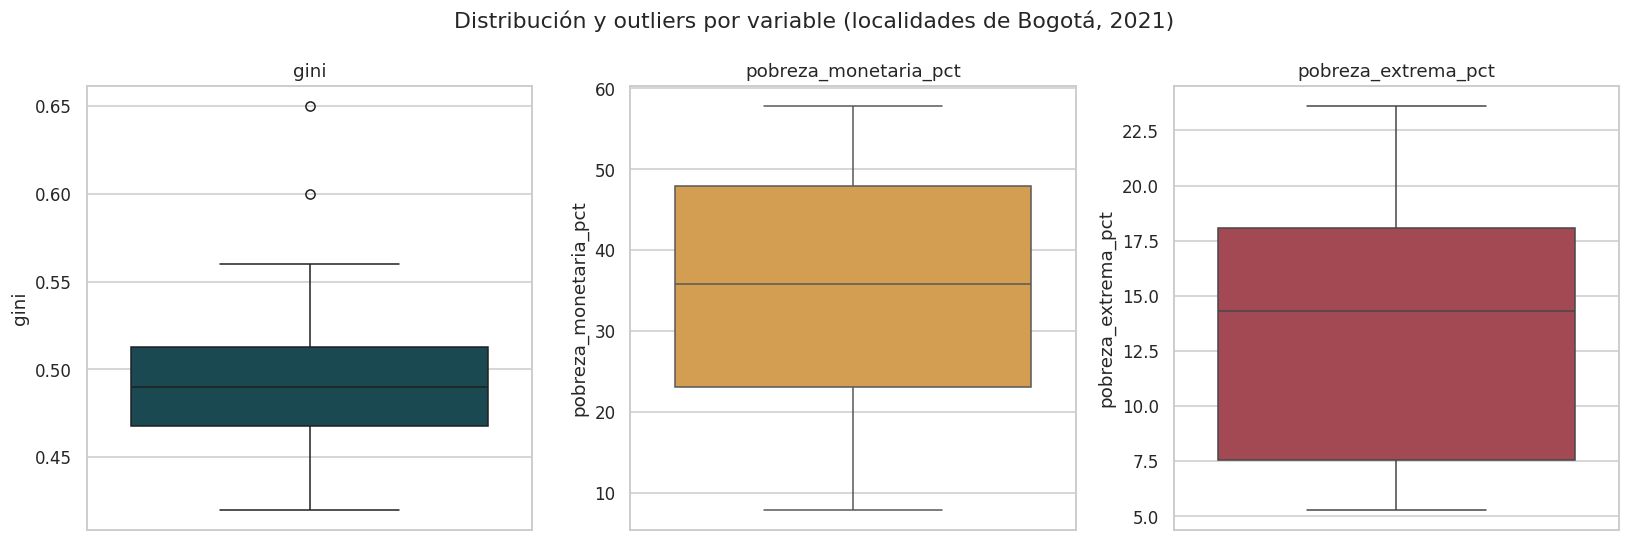

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, var, color in zip(axes, variables, ["#124F5A","#E9A23B","#B23A48"]):
    sns.boxplot(y=loc_2021[var], ax=ax, color=color)
    ax.set_title(var)
plt.suptitle("Distribución y outliers por variable (localidades de Bogotá, 2021)")
plt.tight_layout()
plt.show()

In [10]:
# Identificar outliers con el método del rango intercuartílico (IQR)
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    return serie[(serie < lim_inf) | (serie > lim_sup)]

for var in variables:
    out = outliers_iqr(loc_2021[var])
    if len(out) > 0:
        print(f"Outliers en {var}:")
        print(loc_2021.loc[out.index, ["Localidad", var]])
    else:
        print(f"No hay outliers en {var} (según IQR)")
    print()

Outliers en gini:
        Localidad  gini
8   La Candelaria  0.60
13       Santa Fe  0.65

No hay outliers en pobreza_monetaria_pct (según IQR)

No hay outliers en pobreza_extrema_pct (según IQR)



**Hipótesis que surge de los datos:** Santa Fe aparece como un caso atípico — tiene el Gini más alto (0.65) *y* una pobreza monetaria alta (47.7%), lo que sugiere que allí conviven, dentro de la misma localidad, sectores muy ricos y muy pobres (coherente con su ubicación en el centro histórico de Bogotá, con zonas como La Macarena y también amplias zonas de alta vulnerabilidad).

---
<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Corbel,Calibri,sans-serif">
<span style="font-size:40px;color:#E9A23B;font-weight:bold">03</span>
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">ETAPA 3 · MÓDULO 3</div>
<h2 style="color:#fff;margin:6px 0 0 0">Visualización, modelo predictivo y storytelling</h2>
</div>

### 3.1 · Visualizaciones que cuentan la historia

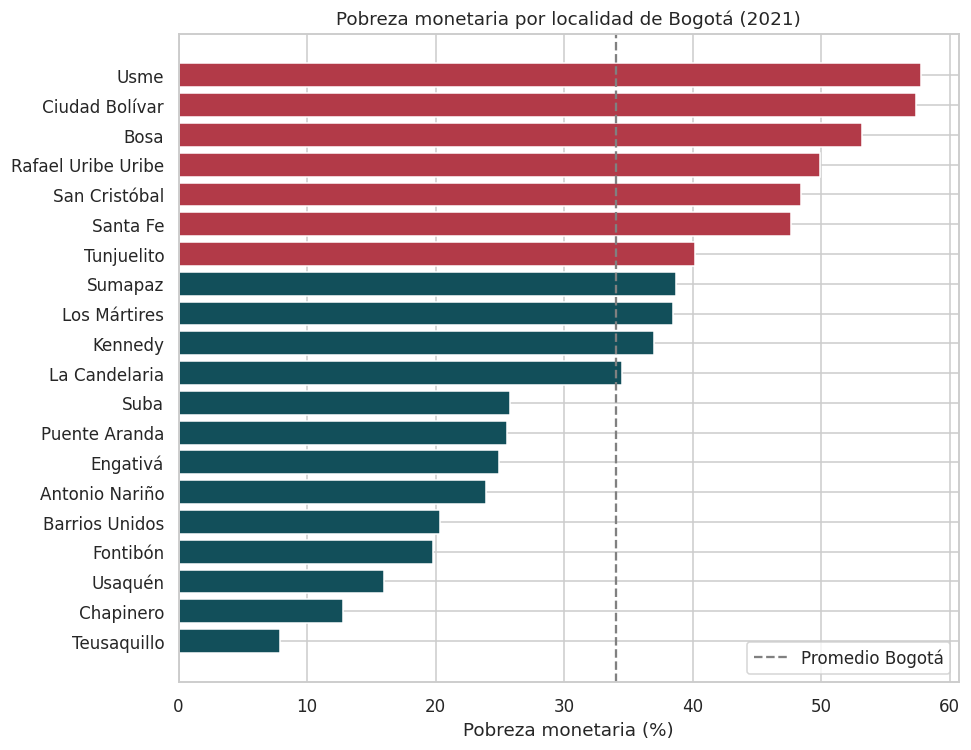

In [11]:
top10 = loc_2021.sort_values("pobreza_monetaria_pct", ascending=False)

plt.figure(figsize=(9,7))
colors = ["#B23A48" if v > 40 else "#124F5A" for v in top10["pobreza_monetaria_pct"]]
plt.barh(top10["Localidad"], top10["pobreza_monetaria_pct"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Pobreza monetaria (%)")
plt.title("Pobreza monetaria por localidad de Bogotá (2021)")
plt.axvline(loc_2021["pobreza_monetaria_pct"].mean(), color="gray", linestyle="--", label="Promedio Bogotá")
plt.legend()
plt.tight_layout()
plt.show()

,gini,pobreza_monetaria_pct,pobreza_extrema_pct
gini,1.000000,-0.010640,0.151001
pobreza_monetaria_pct,-0.010640,1.000000,0.893258
pobreza_extrema_pct,0.151001,0.893258,1.000000


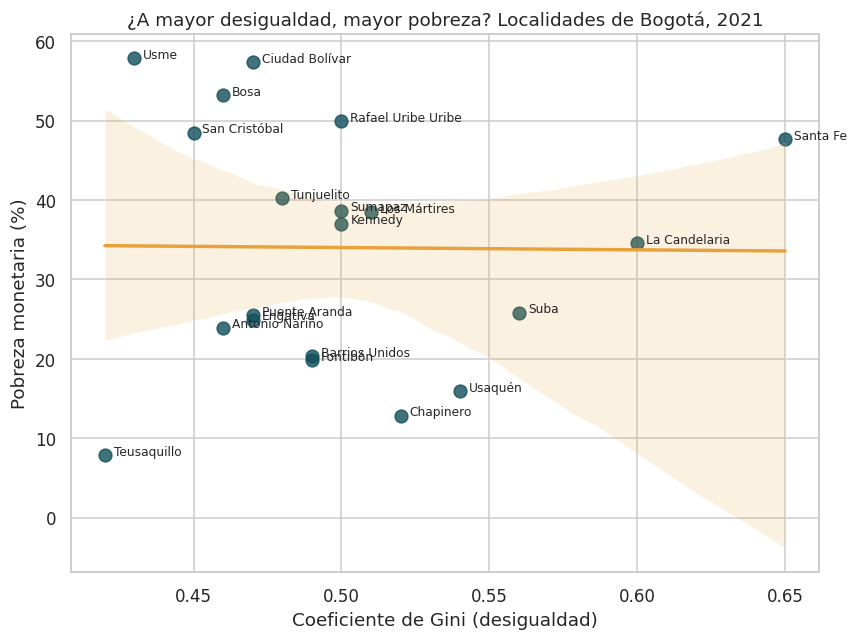

In [12]:
plt.figure(figsize=(8,6))
sns.regplot(data=loc_2021, x="gini", y="pobreza_monetaria_pct",
            scatter_kws={"s":70, "color":"#124F5A"}, line_kws={"color":"#E9A23B"})
for _, row in loc_2021.iterrows():
    plt.text(row["gini"]+0.003, row["pobreza_monetaria_pct"], row["Localidad"], fontsize=8)
plt.xlabel("Coeficiente de Gini (desigualdad)")
plt.ylabel("Pobreza monetaria (%)")
plt.title("¿A mayor desigualdad, mayor pobreza? Localidades de Bogotá, 2021")
plt.tight_layout()
plt.show()

correlacion = loc_2021[["gini","pobreza_monetaria_pct","pobreza_extrema_pct"]].corr()
correlacion

**Hallazgo importante (y contraintuitivo):** la correlación entre `gini` y `pobreza_monetaria_pct` es prácticamente **cero (≈ -0.01)** — es decir, a nivel de localidad, **una localidad más desigual internamente no es necesariamente más pobre**. Tiene sentido si se piensa bien: el Gini mide qué tan repartido está el ingreso *dentro* de una localidad (puede haber una localidad pobre pero homogénea, con Gini bajo, y una localidad como Santa Fe donde conviven ricos y pobres, con Gini alto). En cambio, `pobreza_monetaria_pct` y `pobreza_extrema_pct` sí están fuertemente correlacionadas (≈ 0.89): donde hay más pobreza general, hay proporcionalmente mucha más pobreza extrema.

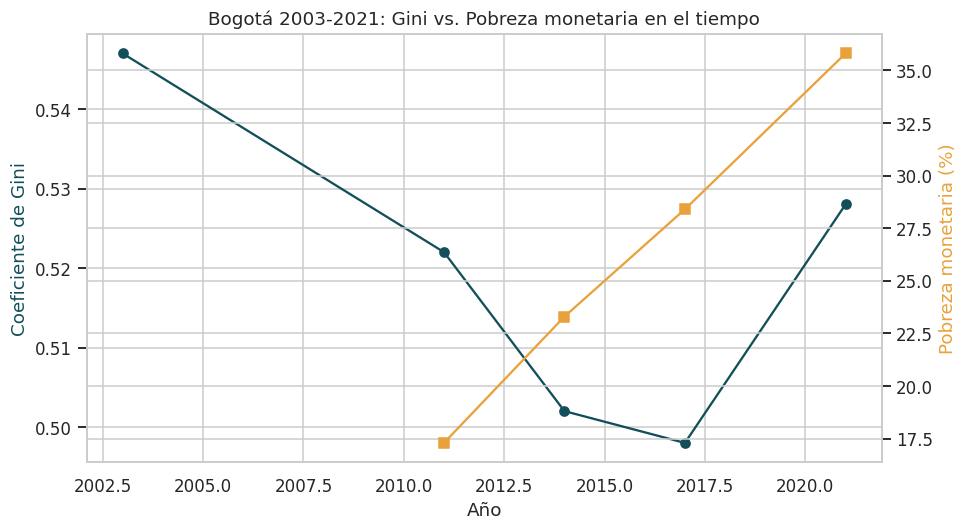

In [13]:
# Serie histórica: cómo ha evolucionado la desigualdad y la pobreza en Bogotá total
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(bogota_total["Año"], bogota_total["gini"], marker="o", color="#124F5A", label="Gini")
ax1.set_ylabel("Coeficiente de Gini", color="#124F5A")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()
ax2.plot(bogota_total["Año"], bogota_total["pobreza_monetaria_pct"], marker="s", color="#E9A23B", label="Pobreza monetaria (%)")
ax2.set_ylabel("Pobreza monetaria (%)", color="#E9A23B")

plt.title("Bogotá 2003-2021: Gini vs. Pobreza monetaria en el tiempo")
fig.tight_layout()
plt.show()

### 3.2 · Modelo predictivo: regresión lineal

Entrenamos una regresión lineal simple para responder la última pregunta de apoyo: **¿el Gini y la pobreza monetaria predicen la pobreza extrema de una localidad?**

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = loc_2021[["gini", "pobreza_monetaria_pct"]]
y = loc_2021["pobreza_extrema_pct"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Coeficientes:")
for var, coef in zip(X.columns, modelo.coef_):
    print(f"  {var}: {coef:.3f}")
print(f"Intercepto: {modelo.intercept_:.3f}")
print(f"\nR² en test: {r2_score(y_test, y_pred):.3f}")
print(f"Error absoluto medio (MAE): {mean_absolute_error(y_test, y_pred):.2f} puntos porcentuales")

Coeficientes:
  gini: 14.701
  pobreza_monetaria_pct: 0.347
Intercepto: -6.390

R² en test: 0.497
Error absoluto medio (MAE): 3.06 puntos porcentuales


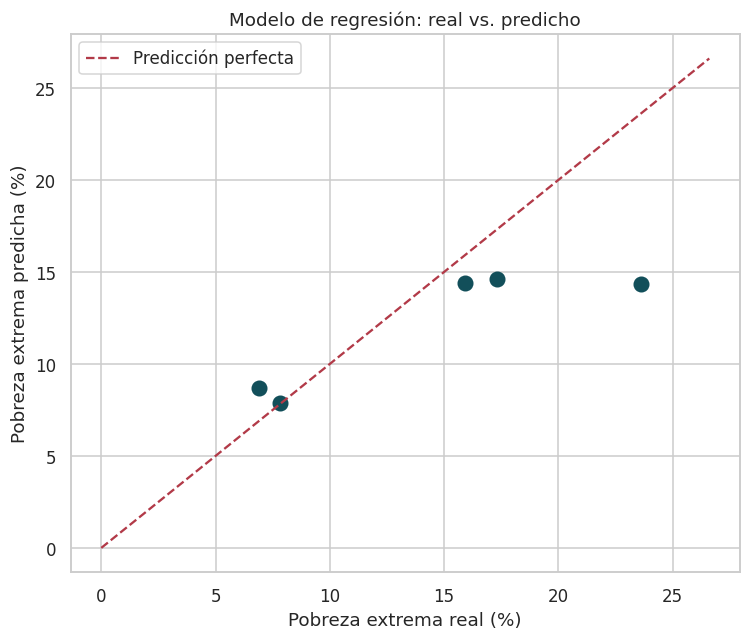

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=90, color="#124F5A")
lims = [0, max(y_test.max(), y_pred.max())+3]
plt.plot(lims, lims, "--", color="#B23A48", label="Predicción perfecta")
plt.xlabel("Pobreza extrema real (%)")
plt.ylabel("Pobreza extrema predicha (%)")
plt.title("Modelo de regresión: real vs. predicho")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación del modelo:** el modelo explica cerca del 50% de la variación en pobreza extrema (R² ≈ 0.50) con un error promedio de ~3 puntos porcentuales. Confirmando lo que vimos en la correlación, `pobreza_monetaria_pct` es, con diferencia, la variable que más pesa en la predicción — el Gini aporta muy poco por sí solo. Esto respalda el hallazgo de la sección anterior: **el nivel general de pobreza de una localidad predice su pobreza extrema mucho mejor que su nivel de desigualdad interna (Gini)**. Con solo 20 localidades el modelo es un ejercicio ilustrativo (no una herramienta de producción), pero muestra el flujo completo: entrenar, predecir y evaluar con R² y MAE.

### 3.3 · Storytelling: resumen y conclusiones

**Lo que encontramos:**
1. La pobreza monetaria varía muchísimo entre localidades (7.9% en Teusaquillo vs. 57.8% en Usme) — Bogotá es una ciudad profundamente desigual en su territorio, no solo en el ingreso individual.
2. El Gini es más parejo entre localidades, pero **Santa Fe** destaca con la desigualdad *interna* más alta — allí conviven extremos de riqueza y pobreza dentro de la misma localidad.
3. **Contrario a lo esperado, el Gini casi no se correlaciona con la pobreza monetaria** (r ≈ -0.01): que una localidad sea internamente desigual no significa que sea más pobre en promedio. Son dos fenómenos distintos que conviene medir por separado — un hallazgo útil para no confundir "desigualdad" con "pobreza" al diseñar política pública.
4. En cambio, la pobreza monetaria sí predice muy bien la pobreza extrema (r ≈ 0.89, R² del modelo ≈ 0.50) — lo que sugiere que las políticas para reducir la pobreza general tendrían efecto directo en reducir la pobreza más severa.
5. A nivel ciudad, entre 2003 y 2017 el Gini bajó (menos desigualdad) pero la pobreza monetaria subió — un hallazgo que invita a explorar más (posiblemente por cambios metodológicos de la encuesta o por choques económicos como la pandemia en 2020-2021).

**Aplicación profesional:** como futuro ingeniero de sistemas, este tipo de análisis es exactamente lo que sustenta un dashboard de política pública o un sistema de apoyo a la decisión para una Secretaría Distrital: identificar qué localidades priorizar con subsidios, monitorear el impacto de programas sociales en el tiempo, o alimentar un modelo más completo (con más variables: educación, acceso a salud, empleo) para predecir riesgo social por zona. Es el mismo flujo de trabajo — cargar, limpiar, explorar, visualizar, modelar — que usaría en un proyecto real de datos abiertos gubernamentales o en un rol de análisis de datos en el sector público o en una ONG.

---
<div style="background:#0A3D45;padding:20px 26px;border-radius:12px;color:#fff;font-family:Corbel,Calibri,sans-serif;border-left:6px solid #E9A23B">
<b>Checklist antes de grabar el video:</b><br>
✅ Explicar la pregunta C.L.A.R.A. y por qué elegiste este dataset (Módulo 1)<br>
✅ Mostrar la limpieza y las medidas estadísticas (Módulo 2)<br>
✅ Mostrar las visualizaciones, el modelo y cerrar con storytelling + aplicación profesional (Módulo 3)<br>
✅ Subir este notebook + tus gráficos a un repositorio de GitHub
</div>